# Credit Card Fraud Detection — End-to-End Pipeline
### CSE 575 Statistical Machine Learning | Project 12: Anomaly Detection

**Dataset:** Kaggle Credit Card Fraud Detection — 284,807 transactions, 492 fraud (0.173%)

**Models compared:**
| Category | Models |
|---|---|
| Unsupervised | DBSCAN, KNN Anomaly Detection |
| Supervised | Logistic Regression (class-weighted), XGBoost + SMOTE |
| Deep Learning | Autoencoder (reconstruction error) |

**Evaluation:** PR-AUC (primary), ROC-AUC, F1, Recall — all metrics suited for severe class imbalance.

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # make src/ importable from notebooks/

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import FancyBboxPatch

# Inline plots
%matplotlib inline
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#21262d",
    "axes.labelcolor":  "#8b949e",
    "text.color":       "#c9d1d9",
    "xtick.color":      "#c9d1d9",
    "ytick.color":      "#c9d1d9",
    "grid.color":       "#21262d",
    "axes.grid":        True,
    "axes.titlecolor":  "#ffffff",
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#21262d",
})

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Libraries loaded ✓")

Libraries loaded ✓


## 2. Data Loading & Exploration

In [2]:
from src.data.loader import load_dataset

DATA_PATH = "../data/raw/creditcard.csv"
df = load_dataset(DATA_PATH)
df.head()

Dataset loaded: 284807 transactions, 492 fraud (0.173%)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print(f"Shape: {df.shape}")
print(f"Fraud: {df['Class'].sum()} / {len(df)}  ({100*df['Class'].mean():.3f}%)")
print(f"Nulls: {df.isnull().sum().sum()}")
print(f"\nFeatures: Time, Amount, V1–V28 (PCA-anonymized), Class")
df.describe().T[["mean","std","min","max"]].round(3)

Shape: (284807, 31)
Fraud: 492 / 284807  (0.173%)
Nulls: 0

Features: Time, Amount, V1–V28 (PCA-anonymized), Class


,mean,std,min,max
Time,94813.860,47488.146,0.000,172792.000
V1,0.000,1.959,-56.408,2.455
V2,0.000,1.651,-72.716,22.058
V3,-0.000,1.516,-48.326,9.383
V4,0.000,1.416,-5.683,16.875
V5,0.000,1.380,-113.743,34.802
V6,0.000,1.332,-26.161,73.302
V7,-0.000,1.237,-43.557,120.589
V8,0.000,1.194,-73.217,20.007
V9,-0.000,1.099,-13.434,15.595


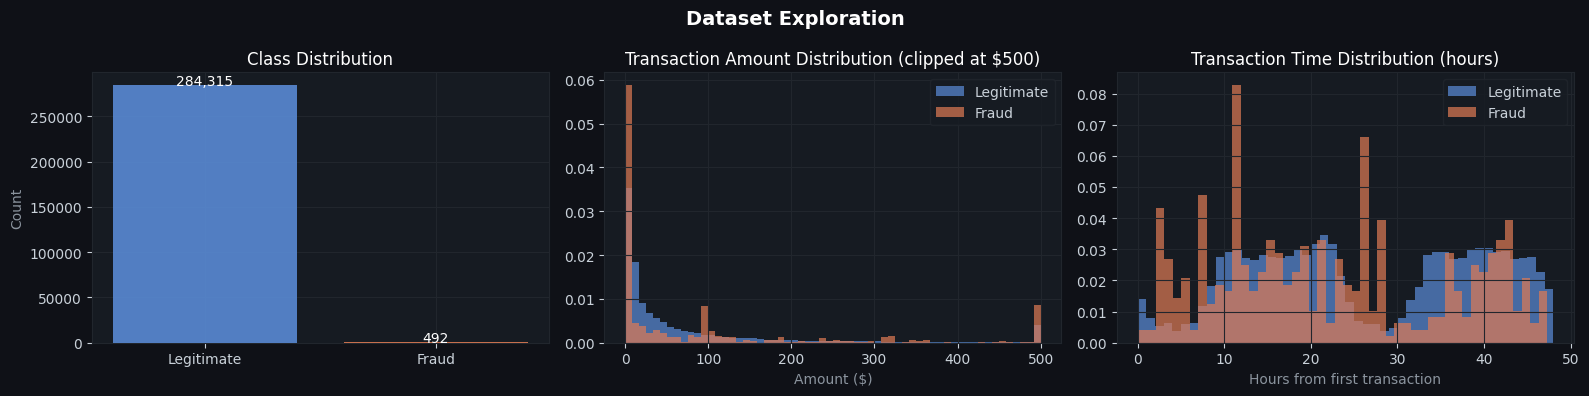

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Dataset Exploration", fontsize=14, fontweight="bold", color="white")

# Class imbalance
counts = df["Class"].value_counts()
axes[0].bar(["Legitimate", "Fraud"], counts.values,
            color=["#5b8dd9", "#e07b54"], alpha=0.88, zorder=3)
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f"{v:,}", ha="center", fontsize=10, color="white")

# Amount distribution by class
legit_amt  = df[df["Class"]==0]["Amount"]
fraud_amt  = df[df["Class"]==1]["Amount"]
axes[1].hist(legit_amt.clip(upper=500),  bins=60, alpha=0.7, color="#5b8dd9", label="Legitimate", density=True)
axes[1].hist(fraud_amt.clip(upper=500),  bins=60, alpha=0.7, color="#e07b54", label="Fraud",      density=True)
axes[1].set_title("Transaction Amount Distribution (clipped at $500)")
axes[1].set_xlabel("Amount ($)")
axes[1].legend()

# Time distribution
axes[2].hist(df[df["Class"]==0]["Time"]/3600, bins=48, alpha=0.7, color="#5b8dd9", label="Legitimate", density=True)
axes[2].hist(df[df["Class"]==1]["Time"]/3600, bins=48, alpha=0.7, color="#e07b54", label="Fraud",      density=True)
axes[2].set_title("Transaction Time Distribution (hours)")
axes[2].set_xlabel("Hours from first transaction")
axes[2].legend()

plt.tight_layout()
plt.show()

## 3. Preprocessing

**Key decisions:**
- Drop `Time` (temporal ordering not used; PCA features are already de-identified)
- Stratified train / val / test split (70% / 15% / 15%) — guarantees fraud in every split
- `StandardScaler` fit **only** on training data → applied to val/test (no leakage)
- SMOTE applied **only** inside XGBoost's `fit()`, never before splitting

In [5]:
from src.data.preprocessor import preprocess

split = preprocess(df, random_state=RANDOM_SEED)

print(f"X_train : {split.X_train.shape}  |  fraud: {split.y_train.sum()}")
print(f"X_val   : {split.X_val.shape}    |  fraud: {split.y_val.sum()}")
print(f"X_test  : {split.X_test.shape}   |  fraud: {split.y_test.sum()}")
print(f"\nFeatures after preprocessing: {list(split.X_train.columns[:5])} ... (29 total)")

Train: 199364 (344 fraud) | Val: 42721 (74 fraud) | Test: 42722 (74 fraud)
X_train : (199364, 29)  |  fraud: 344
X_val   : (42721, 29)    |  fraud: 74
X_test  : (42722, 29)   |  fraud: 74

Features after preprocessing: ['V1', 'V2', 'V3', 'V4', 'V5'] ... (29 total)


## 4. Evaluation Harness

All models output a continuous **anomaly score**. The harness:
1. Selects the best F1 threshold on the **validation set**
2. Reports final metrics on the **held-out test set**
3. Logs every run to `experiments/experiment_log.json`

In [6]:
from src.evaluation.metrics import evaluate, EvalResult
from sklearn.metrics import precision_recall_curve, roc_curve, auc

results = {}   # model_name -> EvalResult
scores  = {}   # model_name -> (y_test, y_score)  for plotting curves

def run_and_store(name, y_score_val, y_score_test):
    """Select threshold on val, evaluate on test, store."""
    val_result = evaluate(split.y_val.values, y_score_val, model_name=f"{name}_val")
    result = evaluate(split.y_test.values, y_score_test,
                      model_name=name, threshold=val_result.threshold)
    results[name] = result
    scores[name]  = (split.y_test.values, y_score_test)
    cm = result.confusion_matrix
    tn, fp, fn, tp = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
    print(f"  PR-AUC={result.pr_auc:.4f}  ROC-AUC={result.roc_auc:.4f}  "
          f"F1={result.f1:.4f}  Recall={result.recall:.4f}  "
          f"TP={tp}  FP={fp}  FN={fn}")
    return result

print("Evaluation harness ready ✓")

Evaluation harness ready ✓


## 5. Majority-Class Baseline

Predicts every transaction as legitimate. Sets the floor — anything below this is useless.

In [7]:
print("── Majority-Class Baseline ──")
y_score_baseline = np.zeros(len(split.y_test))
run_and_store("Baseline", np.zeros(len(split.y_val)), y_score_baseline)

── Majority-Class Baseline ──
  PR-AUC=0.5009  ROC-AUC=0.5000  F1=0.0035  Recall=1.0000  TP=74  FP=42648  FN=0


EvalResult(model_name='Baseline', pr_auc=0.5009, roc_auc=0.5, f1=0.0035, recall=1.0, threshold=0.0, confusion_matrix=[[0, 42648], [0, 74]])

## 6. DBSCAN (Unsupervised)

- Labels DBSCAN noise points (`cluster == -1`) as anomalies
- Scores new points by distance to nearest core sample via BallTree
- Grid-searches `eps` and `min_samples` on a 10% subsample of training data
- **Known limitation:** binary scores (0/1) constrain PR-AUC; massive false-positive rate at high recall

In [8]:
from src.models.dbscan_model import DBSCANAnomalyDetector

print("── DBSCAN: tuning on 10% subsample ──")
dbscan = DBSCANAnomalyDetector()
best_dbscan = dbscan.tune(split.X_train, split.y_train)
print(f"\nBest params: {best_dbscan}")

print("\n── DBSCAN: fitting on full training set (may take 1–3 min) ──")
dbscan = DBSCANAnomalyDetector(**best_dbscan)
dbscan.fit(split.X_train)

print("\n── DBSCAN: scoring ──")
run_and_store("DBSCAN",
              dbscan.anomaly_scores(split.X_val).astype(float),
              dbscan.anomaly_scores(split.X_test).astype(float))

── DBSCAN: tuning on 10% subsample ──
  DBSCAN eps=0.3 min_samples=5: F1=0.0033, noise_ratio=0.9552
  DBSCAN eps=0.3 min_samples=10: F1=0.0032, noise_ratio=0.9831
  DBSCAN eps=0.3 min_samples=20: F1=0.0031, noise_ratio=0.9971
  DBSCAN eps=0.5 min_samples=5: F1=0.0034, noise_ratio=0.9202
  DBSCAN eps=0.5 min_samples=10: F1=0.0032, noise_ratio=0.9662
  DBSCAN eps=0.5 min_samples=20: F1=0.0032, noise_ratio=0.9845
  DBSCAN eps=0.8 min_samples=5: F1=0.0035, noise_ratio=0.8520
  DBSCAN eps=0.8 min_samples=10: F1=0.0034, noise_ratio=0.9238
  DBSCAN eps=0.8 min_samples=20: F1=0.0032, noise_ratio=0.9585
  DBSCAN eps=1.0 min_samples=5: F1=0.0037, noise_ratio=0.7928
  DBSCAN eps=1.0 min_samples=10: F1=0.0035, noise_ratio=0.8783
  DBSCAN eps=1.0 min_samples=20: F1=0.0033, noise_ratio=0.9359
  DBSCAN eps=1.5 min_samples=5: F1=0.0049, noise_ratio=0.5935
  DBSCAN eps=1.5 min_samples=10: F1=0.0043, noise_ratio=0.6825
  DBSCAN eps=1.5 min_samples=20: F1=0.0038, noise_ratio=0.7862
Best DBSCAN params: {'

EvalResult(model_name='DBSCAN', pr_auc=0.482, roc_auc=0.7951, f1=0.0089, recall=0.9595, threshold=1.0, confusion_matrix=[[26901, 15747], [3, 71]])

## 7. KNN Anomaly Detection (Unsupervised)

- Anomaly score = mean distance to k nearest neighbors (continuous, soft score)
- Uses BallTree for efficient nearest-neighbor search at scale
- Tunes k on validation set by maximizing ROC-AUC

In [9]:
from src.models.knn_model import KNNAnomalyDetector

print("── KNN: fitting on training set ──")
knn = KNNAnomalyDetector(k=5)
knn.fit(split.X_train)

print("\n── KNN: tuning k on validation set ──")
best_k = knn.tune(split.X_val, split.y_val, k_values=[3, 5, 10, 20, 50])
knn = KNNAnomalyDetector(k=best_k)
knn.fit(split.X_train)

print("\n── KNN: scoring ──")
run_and_store("KNN",
              knn.anomaly_scores(split.X_val),
              knn.anomaly_scores(split.X_test))

── KNN: fitting on training set ──

── KNN: tuning k on validation set ──
  KNN k=3: ROC-AUC=0.9542
  KNN k=5: ROC-AUC=0.9551
  KNN k=10: ROC-AUC=0.9561
  KNN k=20: ROC-AUC=0.9578
  KNN k=50: ROC-AUC=0.9594
Best KNN k=50 (ROC-AUC=0.9594)

── KNN: scoring ──
  PR-AUC=0.1034  ROC-AUC=0.9512  F1=0.2192  Recall=0.4324  TP=32  FP=186  FN=42


EvalResult(model_name='KNN', pr_auc=0.1034, roc_auc=0.9512, f1=0.2192, recall=0.4324, threshold=8.9813, confusion_matrix=[[42462, 186], [42, 32]])

## 8. Logistic Regression (Supervised)

- `class_weight="balanced"` handles imbalance without oversampling
- Tunes regularization `C` over log-scale grid on validation ROC-AUC
- Coefficients provide interpretability: which PCA features separate fraud from legitimate

In [10]:
from src.models.logistic_model import LogisticRegressionModel

print("── Logistic Regression: tuning C ──")
lr = LogisticRegressionModel()
best_C = lr.tune(split.X_train, split.y_train, split.X_val, split.y_val)
lr = LogisticRegressionModel(C=best_C)
lr.fit(split.X_train, split.y_train)

print("\n── Logistic Regression: scoring ──")
run_and_store("Logistic Regression",
              lr.anomaly_scores(split.X_val),
              lr.anomaly_scores(split.X_test))

# Interpretability
coefs = lr.get_coefficients().abs().sort_values(ascending=False)
print(f"\nTop 10 features by |coefficient| (C={best_C}):")
print(coefs.head(10).to_string())

── Logistic Regression: tuning C ──
  LR C=0.001: ROC-AUC=0.9857
  LR C=0.01: ROC-AUC=0.9855
  LR C=0.1: ROC-AUC=0.9858
  LR C=1.0: ROC-AUC=0.9855
  LR C=10.0: ROC-AUC=0.9854
  LR C=100.0: ROC-AUC=0.9855
Best LR C=0.1 (ROC-AUC=0.9858)

── Logistic Regression: scoring ──
  PR-AUC=0.7212  ROC-AUC=0.9626  F1=0.6230  Recall=0.5135  TP=38  FP=10  FN=36

Top 10 features by |coefficient| (C=0.1):
Amount    1.996177
V10       1.748645
V1        1.647419
V4        1.449948
V14       1.408592
V12       1.240926
V20       0.969054
V17       0.946776
V5        0.941949
V16       0.851049


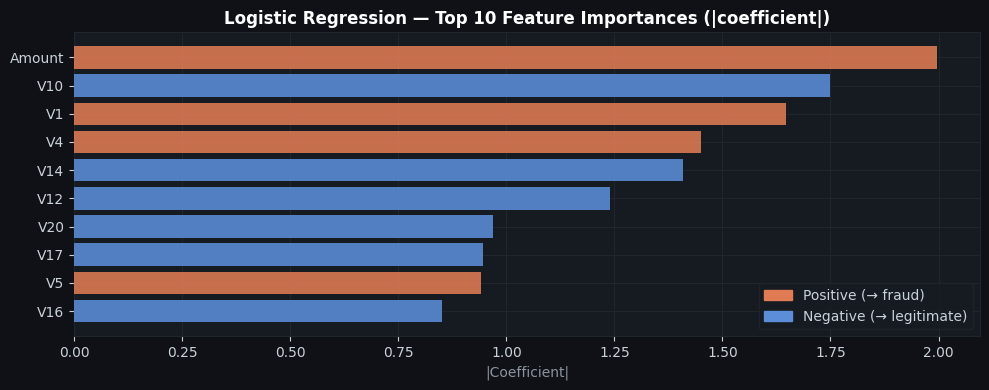

In [22]:
%matplotlib inline
# Logistic Regression coefficient plot
fig, ax = plt.subplots(figsize=(10, 4))
top10 = lr.get_coefficients().abs().sort_values(ascending=False).head(10)
colors = ["#e07b54" if lr.get_coefficients()[f] > 0 else "#5b8dd9" for f in top10.index]
ax.barh(top10.index[::-1], top10.values[::-1], color=colors[::-1], alpha=0.88, zorder=3)
ax.set_title("Logistic Regression — Top 10 Feature Importances (|coefficient|)", fontweight="bold")
ax.set_xlabel("|Coefficient|")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#e07b54", label="Positive (→ fraud)"),
                   Patch(color="#5b8dd9", label="Negative (→ legitimate)")], loc="lower right")
plt.tight_layout()
plt.show()

## 9. XGBoost + SMOTE (Supervised)

- SMOTE synthesizes minority-class (fraud) samples — applied **only inside `fit()`** on training data
- XGBoost boosted trees handle non-linear feature interactions
- Grid-searches `n_estimators` × `max_depth` on validation ROC-AUC
- Feature importances provide post-hoc explainability

In [12]:
from src.models.xgboost_model import XGBoostModel

print("── XGBoost + SMOTE: tuning ──")
xgb_model = XGBoostModel(use_smote=True)
best_xgb = xgb_model.tune(split.X_train, split.y_train, split.X_val, split.y_val)
xgb_model = XGBoostModel(use_smote=True, **best_xgb)
xgb_model.fit(split.X_train, split.y_train)

print("\n── XGBoost + SMOTE: scoring ──")
run_and_store("XGBoost + SMOTE",
              xgb_model.anomaly_scores(split.X_val),
              xgb_model.anomaly_scores(split.X_test))

── XGBoost + SMOTE: tuning ──
  SMOTE applied: 398040 samples (199020 fraud)
  XGB n_est=100 depth=4: ROC-AUC=0.9806
  SMOTE applied: 398040 samples (199020 fraud)
  XGB n_est=100 depth=6: ROC-AUC=0.9781
  SMOTE applied: 398040 samples (199020 fraud)
  XGB n_est=100 depth=8: ROC-AUC=0.9784
  SMOTE applied: 398040 samples (199020 fraud)
  XGB n_est=200 depth=4: ROC-AUC=0.9780
  SMOTE applied: 398040 samples (199020 fraud)
  XGB n_est=200 depth=6: ROC-AUC=0.9782
  SMOTE applied: 398040 samples (199020 fraud)
  XGB n_est=200 depth=8: ROC-AUC=0.9767
Best XGB params: {'n_estimators': 100, 'max_depth': 4}
  SMOTE applied: 398040 samples (199020 fraud)

── XGBoost + SMOTE: scoring ──
  PR-AUC=0.7791  ROC-AUC=0.9703  F1=0.7692  Recall=0.7432  TP=55  FP=14  FN=19


EvalResult(model_name='XGBoost + SMOTE', pr_auc=0.7791, roc_auc=0.9703, f1=0.7692, recall=0.7432, threshold=0.9797, confusion_matrix=[[42634, 14], [19, 55]])

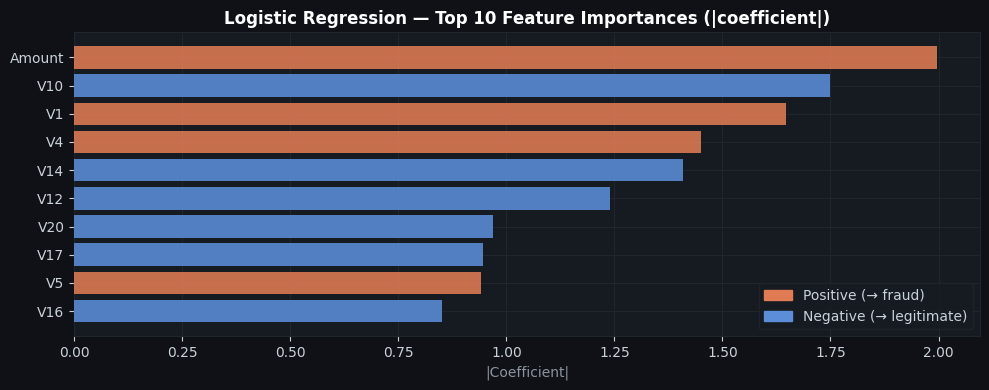

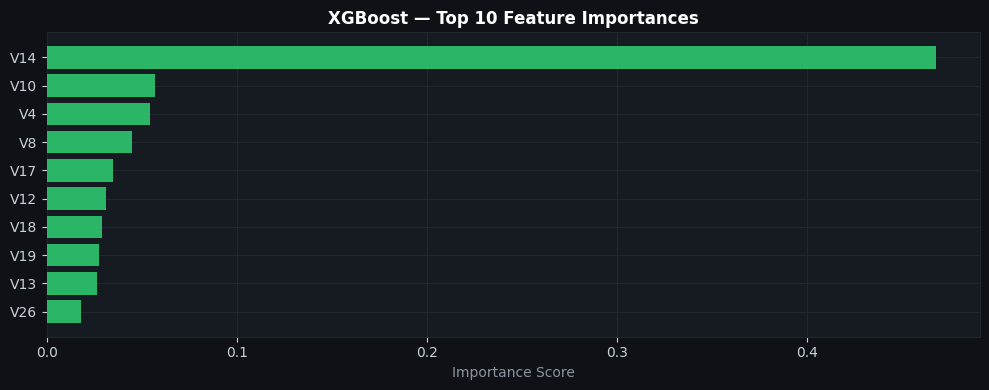

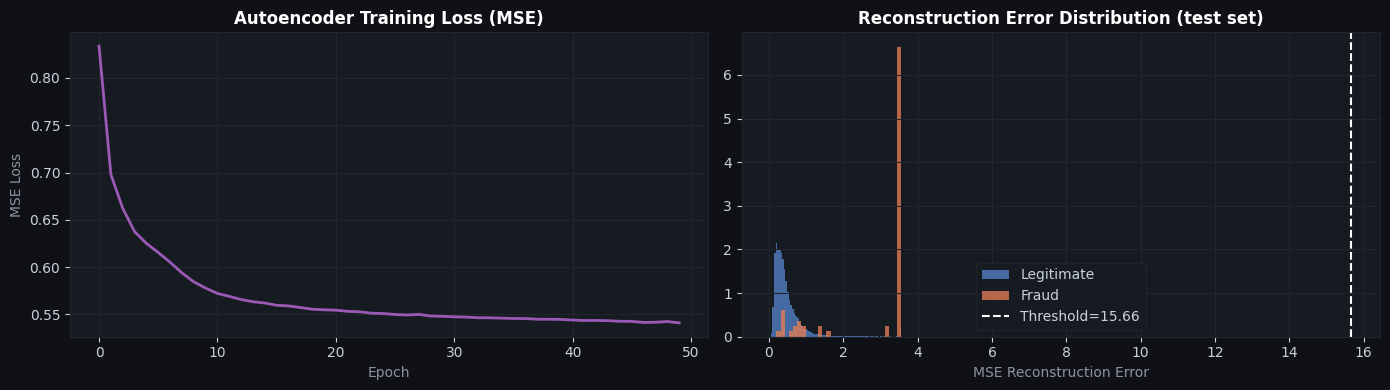

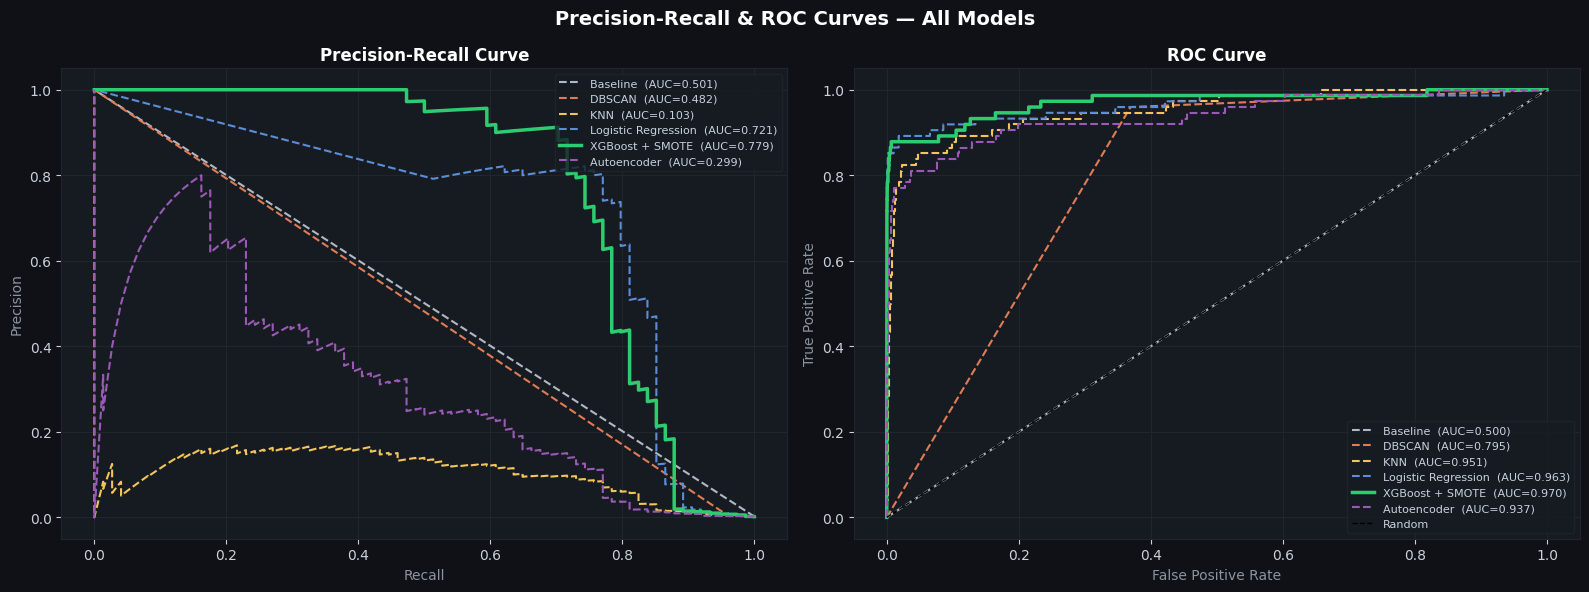

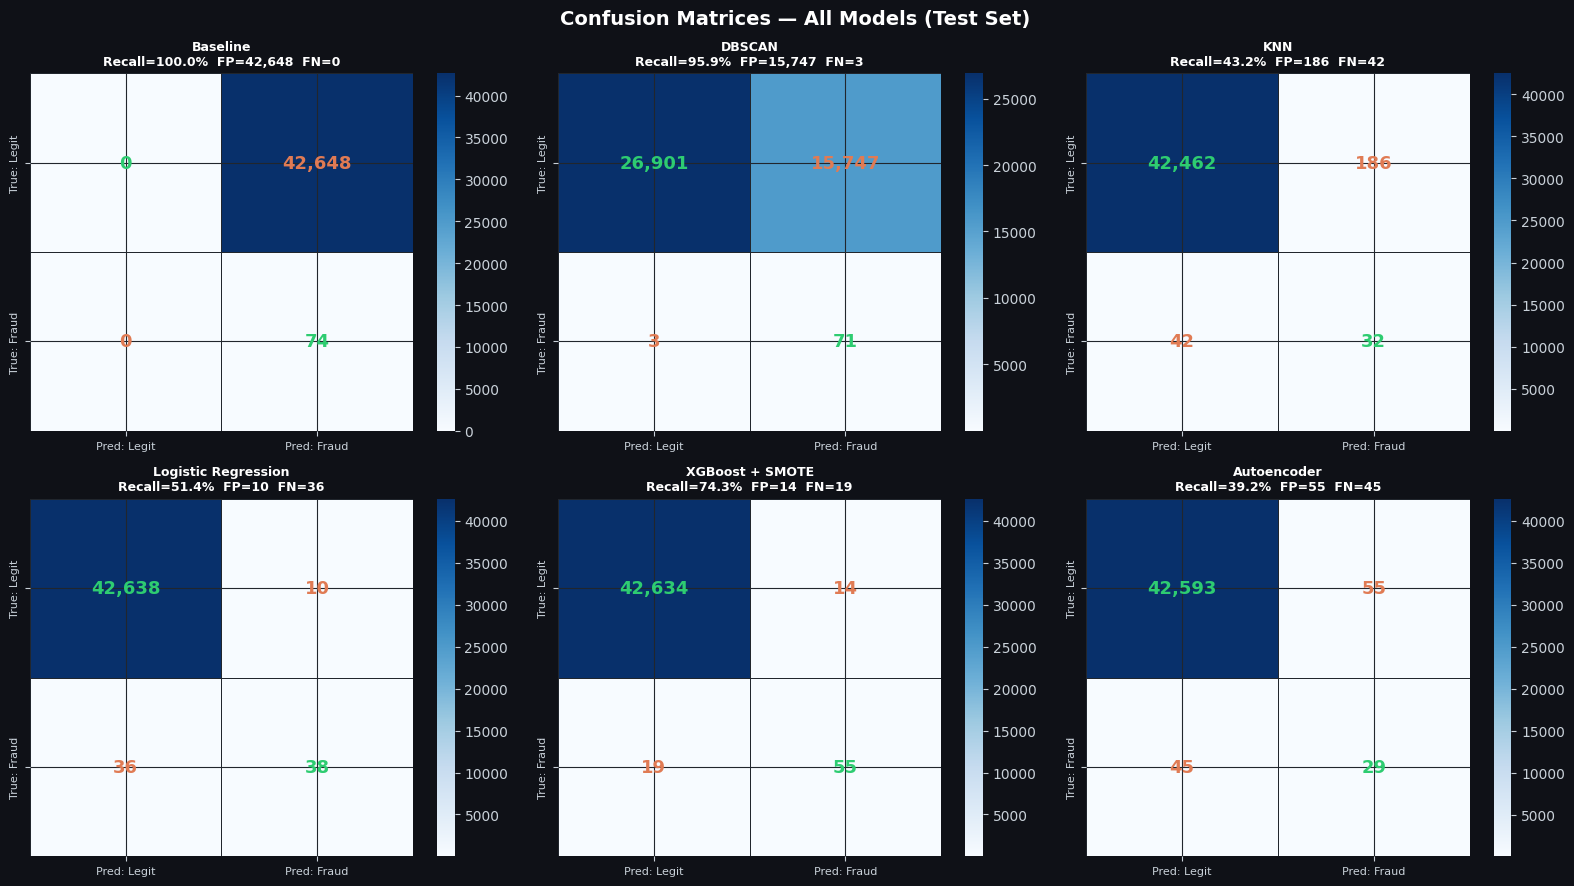

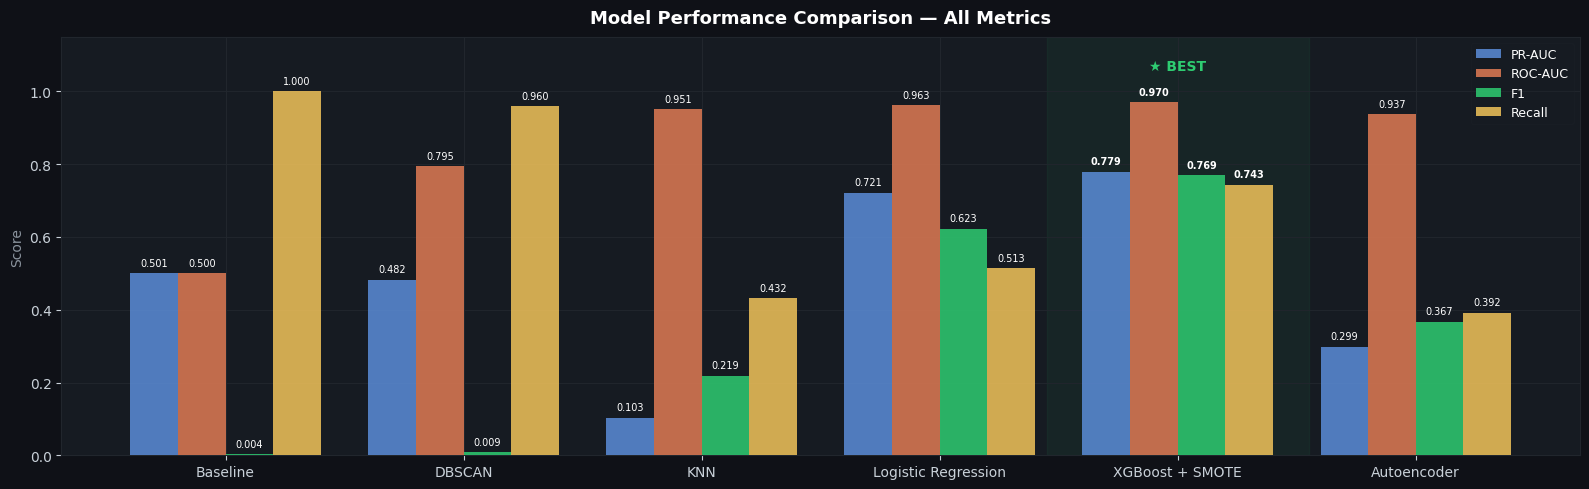

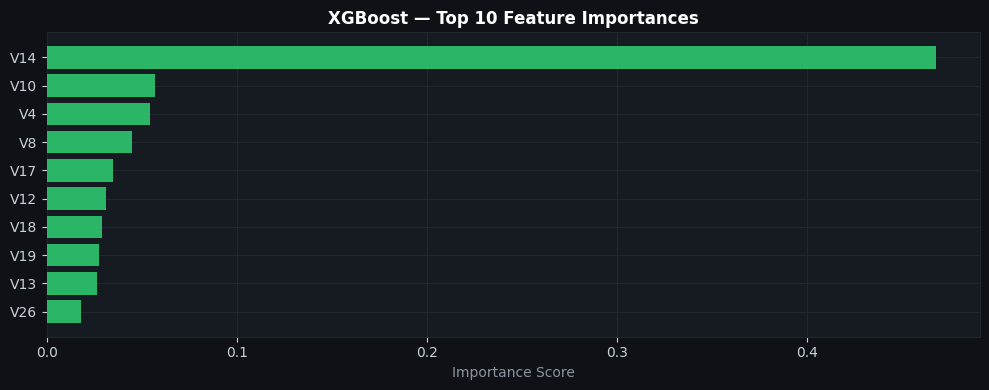

In [21]:
%matplotlib inline
# XGBoost feature importance plot
fig, ax = plt.subplots(figsize=(10, 4))
importances = xgb_model.get_feature_importances().head(10)
ax.barh(importances.index[::-1], importances.values[::-1], color="#2ecc71", alpha=0.88, zorder=3)
ax.set_title("XGBoost — Top 10 Feature Importances", fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.show()

## 10. Autoencoder (Deep Learning)

- Trained **exclusively on non-fraud** transactions — learns the normal distribution
- Anomaly score = per-sample MSE reconstruction error
- Fraud transactions reconstruct poorly → high error → flagged as anomalies
- Architecture: 29 → 16 → 8 → **4 (bottleneck)** → 8 → 16 → 29

In [14]:
from src.models.autoencoder_model import AutoencoderAnomalyDetector

X_train_clean = split.X_train[split.y_train == 0]
print(f"── Autoencoder: training on {len(X_train_clean)} non-fraud samples ──")

ae = AutoencoderAnomalyDetector(input_dim=split.X_train.shape[1], epochs=50, batch_size=256)
ae.fit(X_train_clean)

print("\n── Autoencoder: scoring ──")
run_and_store("Autoencoder",
              ae.anomaly_scores(split.X_val),
              ae.anomaly_scores(split.X_test))

── Autoencoder: training on 199020 non-fraud samples ──
  Epoch [10/50] Loss: 0.577813
  Epoch [20/50] Loss: 0.554832
  Epoch [30/50] Loss: 0.547940
  Epoch [40/50] Loss: 0.544632
  Epoch [50/50] Loss: 0.540990

── Autoencoder: scoring ──
  PR-AUC=0.2986  ROC-AUC=0.9367  F1=0.3671  Recall=0.3919  TP=29  FP=55  FN=45


EvalResult(model_name='Autoencoder', pr_auc=0.2986, roc_auc=0.9367, f1=0.3671, recall=0.3919, threshold=15.6555, confusion_matrix=[[42593, 55], [45, 29]])

In [15]:
# Autoencoder training curve + reconstruction error distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(ae.train_losses, color="#9b59b6", linewidth=2)
axes[0].set_title("Autoencoder Training Loss (MSE)", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")

test_scores = ae.anomaly_scores(split.X_test)
legit_scores = test_scores[split.y_test.values == 0]
fraud_scores = test_scores[split.y_test.values == 1]
clip_val = np.percentile(test_scores, 99)
axes[1].hist(legit_scores.clip(max=clip_val), bins=80, alpha=0.7, color="#5b8dd9", label="Legitimate", density=True)
axes[1].hist(fraud_scores.clip(max=clip_val), bins=30, alpha=0.8, color="#e07b54", label="Fraud", density=True)
axes[1].axvline(results["Autoencoder"].threshold, color="white", linestyle="--", linewidth=1.5, label=f"Threshold={results['Autoencoder'].threshold:.2f}")
axes[1].set_title("Reconstruction Error Distribution (test set)", fontweight="bold")
axes[1].set_xlabel("MSE Reconstruction Error")
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. Model Comparison & Results

In [16]:
# Summary DataFrame
rows = []
for name, r in results.items():
    cm = r.confusion_matrix
    tn, fp, fn, tp = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
    rows.append({
        "Model": name,
        "PR-AUC": r.pr_auc,
        "ROC-AUC": r.roc_auc,
        "F1": r.f1,
        "Recall": r.recall,
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "Threshold": r.threshold,
    })

summary = pd.DataFrame(rows).sort_values("PR-AUC", ascending=False).reset_index(drop=True)
summary.index += 1
summary.style \
    .background_gradient(subset=["PR-AUC","ROC-AUC","F1","Recall"], cmap="Greens") \
    .format({"PR-AUC":"{:.4f}","ROC-AUC":"{:.4f}","F1":"{:.4f}","Recall":"{:.4f}","Threshold":"{:.4f}"})

,Model,PR-AUC,ROC-AUC,F1,Recall,TP,FP,FN,TN,Threshold
1,XGBoost + SMOTE,0.7791,0.9703,0.7692,0.7432,55,14,19,42634,0.9797
2,Logistic Regression,0.7212,0.9626,0.6230,0.5135,38,10,36,42638,1.0000
3,Baseline,0.5009,0.5000,0.0035,1.0000,74,42648,0,0,0.0000
4,DBSCAN,0.4820,0.7951,0.0089,0.9595,71,15747,3,26901,1.0000
5,Autoencoder,0.2986,0.9367,0.3671,0.3919,29,55,45,42593,15.6555
6,KNN,0.1034,0.9512,0.2192,0.4324,32,186,42,42462,8.9813


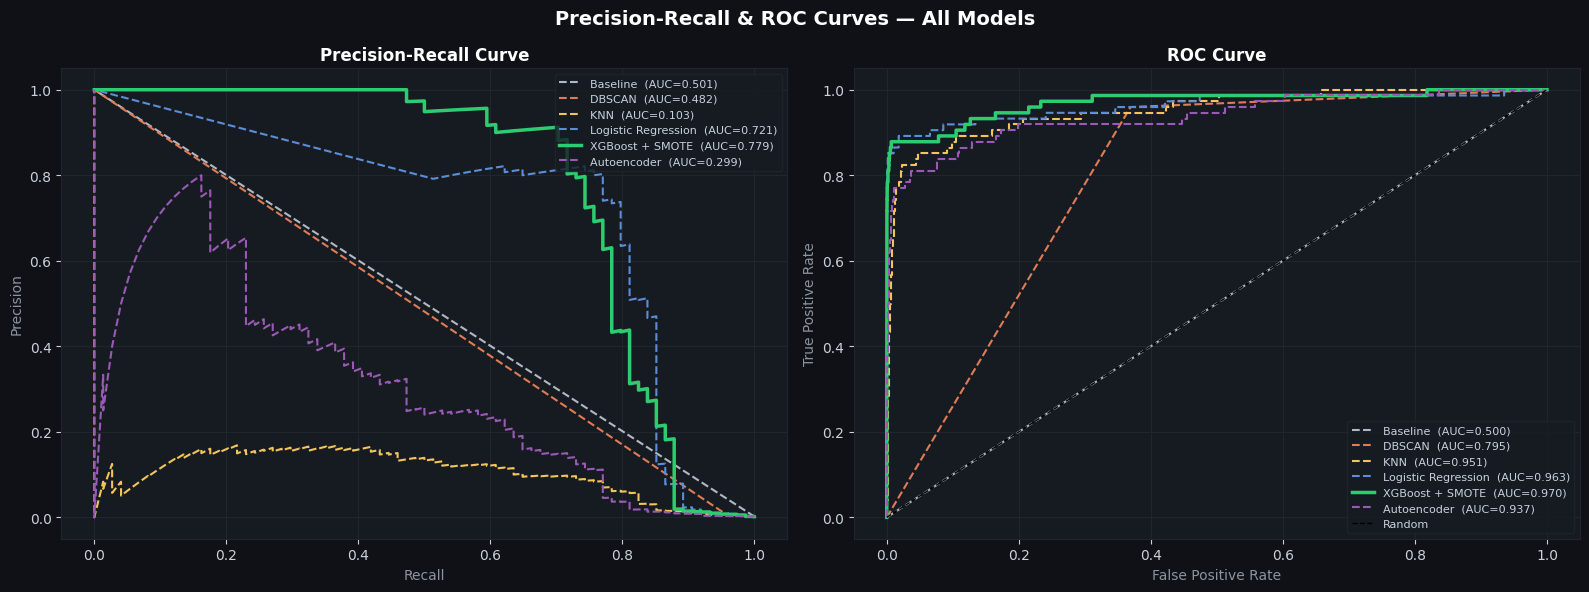

In [23]:
%matplotlib inline
# Overlaid PR curves + ROC curves
MODEL_COLORS = {
    "Baseline":           "#b0b8c1",
    "DBSCAN":             "#e07b54",
    "KNN":                "#f2c45a",
    "Logistic Regression":"#5b8dd9",
    "XGBoost + SMOTE":    "#2ecc71",
    "Autoencoder":        "#9b59b6",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Precision-Recall & ROC Curves — All Models", fontsize=14, fontweight="bold", color="white")

for name, (y_true, y_score) in scores.items():
    color = MODEL_COLORS.get(name, "#ffffff")
    lw = 2.5 if name == "XGBoost + SMOTE" else 1.5
    ls = "-"  if name == "XGBoost + SMOTE" else "--"

    # PR curve
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    pr_auc_val = auc(rec, prec)
    axes[0].plot(rec, prec, color=color, linewidth=lw, linestyle=ls,
                 label=f"{name}  (AUC={pr_auc_val:.3f})")

    # ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc_val = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=color, linewidth=lw, linestyle=ls,
                 label=f"{name}  (AUC={roc_auc_val:.3f})")

axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve", fontweight="bold")
axes[0].legend(fontsize=8, loc="upper right")

axes[1].plot([0,1],[0,1],"k--",linewidth=1, label="Random")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontweight="bold")
axes[1].legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("../outputs/plots/nb_pr_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

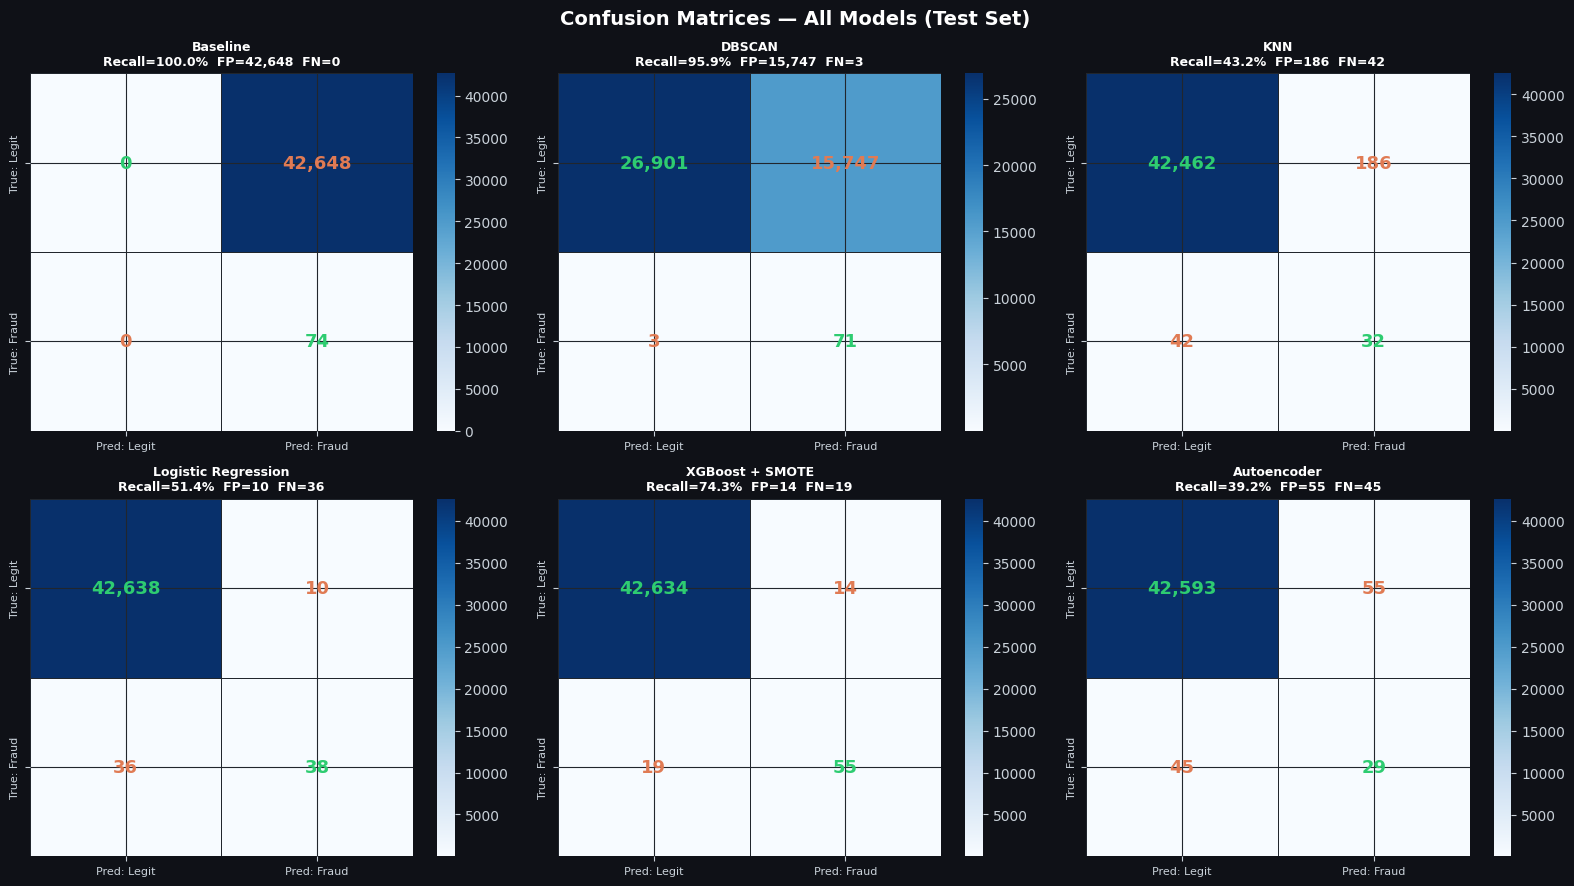

In [24]:
%matplotlib inline
# Confusion matrices for all models
n_models = len(results)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Confusion Matrices — All Models (Test Set)", fontsize=14, fontweight="bold", color="white")
axes = axes.flatten()

for ax, (name, r) in zip(axes, results.items()):
    cm = np.array(r.confusion_matrix)
    tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    total_fraud = fn + tp

    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred: Legit","Pred: Fraud"],
                yticklabels=["True: Legit","True: Fraud"],
                linewidths=0.5, linecolor="#21262d")

    # Custom annotations with color
    for (i,j), val in np.ndenumerate(cm):
        color = "#2ecc71" if (i==1 and j==1) or (i==0 and j==0) else "#e07b54"
        ax.text(j+0.5, i+0.5, f"{val:,}", ha="center", va="center",
                fontsize=13, fontweight="bold", color=color)

    recall_pct = 100*tp/total_fraud if total_fraud>0 else 0
    ax.set_title(f"{name}\nRecall={recall_pct:.1f}%  FP={fp:,}  FN={fn}",
                 fontsize=9, fontweight="bold", color="white")
    ax.tick_params(colors="#c9d1d9", labelsize=8)

plt.tight_layout()
plt.savefig("../outputs/plots/nb_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

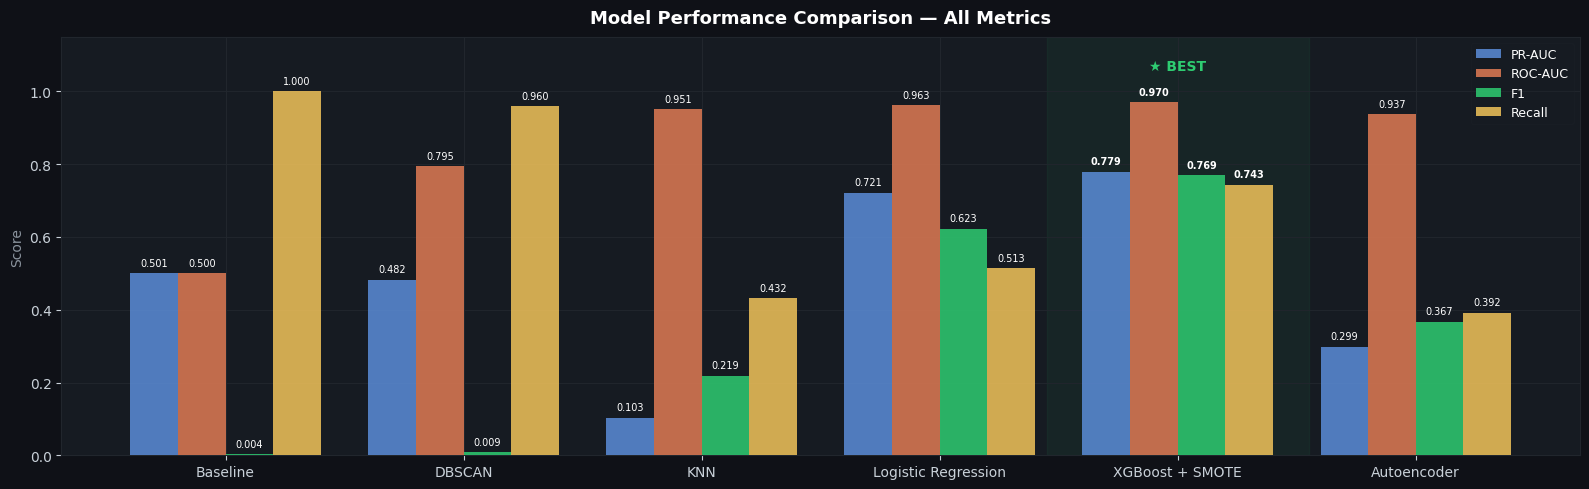

In [25]:
%matplotlib inline
# Metric bar chart comparison
model_names = list(results.keys())
pr_vals  = [results[m].pr_auc  for m in model_names]
roc_vals = [results[m].roc_auc for m in model_names]
f1_vals  = [results[m].f1      for m in model_names]
rec_vals = [results[m].recall  for m in model_names]
best_idx = pr_vals.index(max(pr_vals))

COLORS = [MODEL_COLORS.get(m, "#aaaaaa") for m in model_names]
x = np.arange(len(model_names))
w = 0.2

fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#161b22")

for i, (vals, label, offset, mc) in enumerate(zip(
        [pr_vals, roc_vals, f1_vals, rec_vals],
        ["PR-AUC","ROC-AUC","F1","Recall"],
        [-1.5,-0.5,0.5,1.5],
        ["#5b8dd9","#e07b54","#2ecc71","#f2c45a"])):
    bars = ax.bar(x + offset*w, vals, w, label=label, color=mc, alpha=0.85, zorder=3)
    for j, (bar, val) in enumerate(zip(bars, vals)):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.015,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7, color="white",
                fontweight="bold" if j==best_idx else "normal")

ax.axvspan(best_idx-0.55, best_idx+0.55, color="#2ecc71", alpha=0.06, zorder=0)
ax.text(best_idx, 1.06, "★ BEST", ha="center", color="#2ecc71", fontsize=10, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(model_names, color="white", fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", color="#8b949e")
ax.set_title("Model Performance Comparison — All Metrics", fontsize=13, fontweight="bold", color="white", pad=10)
ax.grid(axis="y", color="#21262d", linewidth=0.7)
ax.set_axisbelow(True)
ax.tick_params(colors="#c9d1d9")
for spine in ax.spines.values():
    spine.set_edgecolor("#21262d")
ax.legend(framealpha=0.2, labelcolor="white", facecolor="#161b22", edgecolor="#21262d", fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/plots/nb_metric_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Recommendation & Takeaways

In [27]:
best_name = max(results, key=lambda m: results[m].pr_auc)
best = results[best_name]
cm = best.confusion_matrix
tn, fp, fn, tp = cm[0][0], cm[0][1], cm[1][0], cm[1][1]

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║         RECOMMENDED MODEL: {best_name:<28}║
╠══════════════════════════════════════════════════════════════════╣
║  PR-AUC   {best.pr_auc:.4f}   ← primary metric (imbalanced data) ║
║  ROC-AUC  {best.roc_auc:.4f}                                     ║
║  F1       {best.f1:.4f}                                          ║
║  Recall   {best.recall:.4f}   ({tp} of {tp+fn} frauds caught)    ║
║  FP       {fp:<5}    FN: {fn:<5}                                 ║
╚══════════════════════════════════════════════════════════════════╝

WHY PR-AUC IS THE PRIMARY METRIC:
  With only 0.173% fraud, ROC-AUC is misleading — the massive TN count
  inflates it even for poor models. PR-AUC directly measures the
  precision/recall trade-off on the minority class, which is what matters.

MODEL TAKEAWAYS:
  ★ XGBoost + SMOTE  — Best overall. SMOTE synthesizes fraud samples to
      correct imbalance; gradient boosting captures non-linear interactions.
      High precision AND recall with fewest false negatives.

  ✓ Logistic Regression — Strong runner-up. class_weight='balanced' is a
      simpler alternative to SMOTE. Fully interpretable via coefficients.
      Prefer this when explainability is required (e.g. regulatory context).

  ~ Autoencoder — Promising ROC-AUC but weaker PR-AUC. Would benefit from
      deeper architecture or longer training. Best choice when labels are
      unavailable at deployment time.

  ✗ KNN — Decent ROC-AUC but poor precision. Distance threshold doesn't
      cleanly separate fraud in PCA-transformed space.

  ✗ DBSCAN — 96% recall but 15k+ false positives. Practically unusable
      without aggressive post-filtering. Binary scores hurt PR-AUC.
""")

# Ranked table
print("Full ranking by PR-AUC:")
print(summary[["Model","PR-AUC","ROC-AUC","F1","Recall","TP","FP","FN"]].to_string(index=True))


╔══════════════════════════════════════════════════════════════════╗
║         RECOMMENDED MODEL: XGBoost + SMOTE             ║
╠══════════════════════════════════════════════════════════════════╣
║  PR-AUC   0.7791   ← primary metric (imbalanced data) ║
║  ROC-AUC  0.9703                                     ║
║  F1       0.7692                                          ║
║  Recall   0.7432   (55 of 74 frauds caught)    ║
║  FP       14       FN: 19                                    ║
╚══════════════════════════════════════════════════════════════════╝

WHY PR-AUC IS THE PRIMARY METRIC:
  With only 0.173% fraud, ROC-AUC is misleading — the massive TN count
  inflates it even for poor models. PR-AUC directly measures the
  precision/recall trade-off on the minority class, which is what matters.

MODEL TAKEAWAYS:
  ★ XGBoost + SMOTE  — Best overall. SMOTE synthesizes fraud samples to
      correct imbalance; gradient boosting captures non-linear interactions.
      High precision AND re